In [1]:
# Definimos la función
def calcular_propina(propina, cuenta):
    porcentaje = propina / cuenta * 100
    return round(porcentaje, 2)

# La usamos
print(calcular_propina(25, 150))
print(calcular_propina(30, 200))
print(calcular_propina(15, 90))

16.67
15.0
16.67


In [3]:
import pandas as pd
import seaborn as sns

def preparar_dataset(nombre_dataset):
    """
    Carga un dataset de seaborn, muestra info básica,
    y regresa el DataFrame listo para analizar.
    """
    # Cargamos el dataset
    df = sns.load_dataset(nombre_dataset)
    
    # Mostramos info básica automáticamente
    print(f"Dataset: {nombre_dataset}")
    print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
    print(f"Valores faltantes:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print("-" * 40)
    
    return df

# Probamos con dos datasets distintos
titanic = preparar_dataset('titanic')
tips = preparar_dataset('tips')

Dataset: titanic
Filas: 891, Columnas: 15
Valores faltantes:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64
----------------------------------------
Dataset: tips
Filas: 244, Columnas: 7
Valores faltantes:
Series([], dtype: int64)
----------------------------------------


=== Análisis de 'age' ===
Promedio:  29.70
Mediana:   28.00
Std:       14.53
Min:       0.42
Max:       80.00
Faltantes: 177


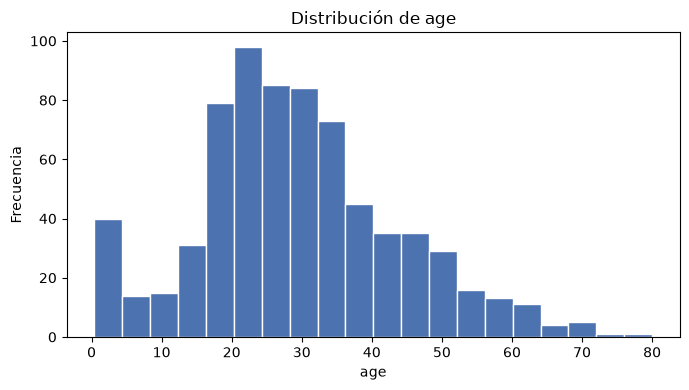

=== Análisis de 'total_bill' ===
Promedio:  19.79
Mediana:   17.80
Std:       8.90
Min:       3.07
Max:       50.81
Faltantes: 0


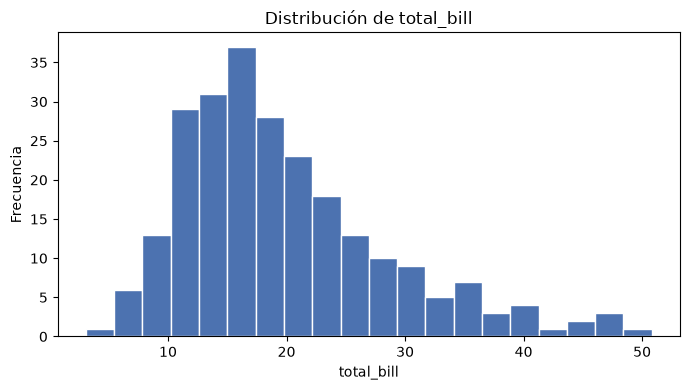

In [4]:
import matplotlib.pyplot as plt

def analizar_columna(df, columna):
    """
    Genera estadísticas y una gráfica rápida de una columna numérica.
    """
    print(f"=== Análisis de '{columna}' ===")
    print(f"Promedio:  {df[columna].mean():.2f}")
    print(f"Mediana:   {df[columna].median():.2f}")
    print(f"Std:       {df[columna].std():.2f}")
    print(f"Min:       {df[columna].min():.2f}")
    print(f"Max:       {df[columna].max():.2f}")
    print(f"Faltantes: {df[columna].isnull().sum()}")
    
    # Histograma automático
    plt.figure(figsize=(7, 4))
    plt.hist(df[columna].dropna(), bins=20, color='#4C72B0', edgecolor='white')
    plt.title(f'Distribución de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

# Probamos con varias columnas de distintos datasets
analizar_columna(titanic, 'age')
analizar_columna(tips, 'total_bill')

In [5]:
def detectar_outliers(df, columna):
    """
    Detecta outliers usando la regla de 3 desviaciones estándar.
    Regresa un DataFrame con solo las filas atípicas.
    """
    media = df[columna].mean()
    std = df[columna].std()
    limite_superior = media + 3 * std
    limite_inferior = media - 3 * std
    
    outliers = df[(df[columna] > limite_superior) | (df[columna] < limite_inferior)]
    
    print(f"=== Outliers en '{columna}' ===")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Outliers encontrados: {len(outliers)}")
    
    return outliers

# Probamos
outliers_edad = detectar_outliers(titanic, 'age')
print(outliers_edad[['age']].head())

outliers_tarifa = detectar_outliers(titanic, 'fare')
print(outliers_tarifa[['fare']].head())

=== Outliers en 'age' ===
Límite inferior: -13.88
Límite superior: 73.28
Outliers encontrados: 2
      age
630  80.0
851  74.0
=== Outliers en 'fare' ===
Límite inferior: -116.88
Límite superior: 181.28
Outliers encontrados: 20
         fare
27   263.0000
88   263.0000
118  247.5208
258  512.3292
299  247.5208
